In [1]:
import torch
import torch.nn as nn

from dm_control import mujoco
import numpy as np
import os

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output


device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
MIN_NUM_ANCHORS = 200
MAX_NUM_ANCHORS = 200
EPISODE_LENGTH = 200
NUM_RANDOM_STEPS = 50
STATE_SCALE = 1
Z_DIM = 128

ENTROPY_COEF = 1e-2
DISCOUNT_FACTOR = 0.95

X1_RANGE, X2_RANGE = 0.25 * STATE_SCALE, 0.175 * STATE_SCALE
# X1_RANGE, X2_RANGE = 0.3 * STATE_SCALE, 0.3 * STATE_SCALE

# Reward Generator:

In [3]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)
        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [4]:
# fre_network = FRENetwork(obs_len=2)
# fre_network.load_state_dict(torch.load('models/reward_generator.pth'))
# statistics = torch.load('models/reward_generator_mean_std.pth')
# emperical_mean = statistics['emperical_mean']
# emperical_std = statistics['emperical_std']

In [5]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network: FRENetwork, min_num_anchors, max_num_anchors, from_buffer, max_buffer_size=1e6):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.emperical_mean = torch.zeros((Z_DIM,), dtype=torch.float32, device=device)
        self.emperical_std  = torch.ones((Z_DIM,), dtype=torch.float32, device=device)    
    
        self.from_buffer = from_buffer
        self.new_states_buffer = None
        self.new_actions_buffer = None
        self.new_zs_buffer = None
        
        self.states_buffer = None
        
        self.max_buffer_size = max_buffer_size
        
        self.std = 1
        
        self.len_params = Z_DIM
        
        self.min_num_anchors = min_num_anchors
        self.max_num_anchors = max_num_anchors
        
        self.resampling_weights = None
        
        self.pre_computed_zs = None
        
    def update_states_buffer(self, new_states):

        # num_trajectories, len_trajectory, obs_dim = new_states.shape
        # for i in range(num_trajectories):
        #     if len(self.states_buffer) < self.max_buffer_size:
        #         self.states_buffer.append(new_states[i].cpu())
        #     else:
        #         j = random.randint(0, self.max_buffer_size-1)
        #         self.states_buffer[j] = new_states[i].cpu()
        
        if self.states_buffer is None:
            self.states_buffer = new_states
        else:
            self.states_buffer = torch.concatenate((self.states_buffer, new_states), dim=0)
        
    
    def update_new_states_buffer(self, new_states, new_actions):
        if self.new_states_buffer is None:
            self.new_states_buffer = new_states
            self.new_actions_buffer = new_actions
        else:
            self.new_states_buffer = torch.concatenate((self.new_states_buffer, new_states), dim=0)
            self.new_actions_buffer = torch.concatenate((self.new_actions_buffer, new_actions), dim=0)

    
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    
    def get_intermediate_anchors(self, anchors, anchors_rewards, num_intermediate_anchors:int):
        
        batch_size, num_anchors = anchors.shape[0], anchors.shape[1]

        intermediate_anchors = []
        intermediate_rewards = []
        for b in range(batch_size):
            # alpha = torch.rand((num_intermediate_anchors, num_anchors-1, 1))
            alpha = torch.linspace(0, 1, num_intermediate_anchors+2)[1:-1].unsqueeze(-1).repeat(1, num_anchors-1).unsqueeze(-1)
            
            x = (1-alpha)*anchors[b, :-1] + alpha*anchors[b, 1:]
            x = x.permute(1, 0, 2)
            
            r = (1-alpha)*anchors_rewards[b, :-1] + alpha*anchors_rewards[b, 1:]
            r = r.permute(1, 0, 2)
            
            x = x.reshape(-1, 2)
            r = r.reshape(-1, 1)
            
            intermediate_anchors.append(x)
            intermediate_rewards.append(r)
            
        intermediate_anchors = torch.stack(intermediate_anchors)
        intermediate_rewards = torch.stack(intermediate_rewards)

        return intermediate_anchors, intermediate_rewards
        # anchors.shape, intermediate_anchors.shape, intermediate_rewards.shape
    
    def get_importance_sampling_indices(self, N):
        indices = torch.multinomial(self.resampling_weights, N, replacement=True)
        return indices
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors, num_states, num_intermediate_anchors=10, from_new_states=False, trajectories_idx_=None,
                          anchors_from_same_trajectory=True):
        assert min_num_anchors <= max_num_anchors <= num_states

        obs_dim = self.obs_dim
        
        all_states = torch.zeros((batch_size, num_states, obs_dim), dtype=torch.float32)
        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)
        
        buffer = self.new_states_buffer if from_new_states else self.states_buffer
        assert buffer is not None
        
        num_trajectories, trajectory_length = buffer.shape[0], buffer.shape[1]
        
        # Get anchors:
        # trajectories_idx_ = torch.randint(0, num_trajectories, (batch_size, 1))
        
        if anchors_from_same_trajectory:
            if trajectories_idx_ is None:
                trajectories_idx_ = self.get_importance_sampling_indices(batch_size)
            trajectories_idx_ = trajectories_idx_.unsqueeze(-1)
            trajectories_idx = trajectories_idx_.repeat(1, max_num_anchors).reshape(-1)
            states_idx = torch.linspace(0, trajectory_length-1, max_num_anchors).long().repeat(batch_size)
        else:
            trajectories_idx = self.get_importance_sampling_indices(max_num_anchors*batch_size)
            trajectories_idx_ = trajectories_idx
            states_idx = torch.randint(0, buffer.shape[1], (max_num_anchors*batch_size,))
            
        base_states_idx = torch.linspace(0, EPISODE_LENGTH-1, max_num_anchors).long().repeat(batch_size)
        # states_idx = torch.concatenate([torch.linspace(0, torch.randint(EPISODE_LENGTH, trajectory_length-1, (1,)).item(), max_num_anchors).long() for _ in range(batch_size)])
        
        # states_idx = torch.randint(1, trajectory_length-1, (batch_size, max_num_anchors))
        # states_idx[:, 0] = 0
        # states_idx[:, -1] = trajectory_length-1
        # states_idx = states_idx.sort().values.reshape(-1).long()
        
        anchors = buffer[trajectories_idx, states_idx, :2]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)
        all_states[:, :max_num_anchors, :] = anchors
        
        # Get the anchors for the base part of the trajectory:
        base_anchors = buffer[trajectories_idx, base_states_idx, :2]
        base_anchors = base_anchors.reshape(batch_size, max_num_anchors, obs_dim)
        
        # Get non anchors
        num_non_anchors = num_states - max_num_anchors
        # trajectories_idx = torch.randint(0, buffer.shape[0], (num_non_anchors*batch_size,))
        trajectories_idx = self.get_importance_sampling_indices(num_non_anchors*batch_size)
        states_idx       = torch.randint(0, buffer.shape[1], (num_non_anchors*batch_size,))
        non_anchors = buffer[trajectories_idx, states_idx, :2]
        non_anchors = non_anchors.reshape(batch_size, num_non_anchors, obs_dim)
        all_states[:, max_num_anchors:, :] = non_anchors
        
            
        rewards = torch.zeros((batch_size, num_states), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)
        
        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))
        
        reward_indices = torch.arange(num_states).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)
        if anchors_from_same_trajectory:
            rewards[reward_mask] = torch.linspace(0.3, 1, max_num_anchors).unsqueeze(0).repeat(batch_size, 1).reshape(-1)
        else:
            # rewards[reward_mask] = torch.rand(max_num_anchors*batch_size).reshape(-1)
            # candidates = torch.tensor([0.01, 0.01, 0.01, 0.01, 0.25, 0.25, 0.25, 0.5, 0.5, 1.])
            candidates = torch.tensor([0.0, 0.25, 0.5, 0.75])
            rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (max_num_anchors*batch_size,))]
            rewards[:, max_num_anchors-1] = 1.
            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        rewards = rewards.unsqueeze(-1)
        
        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
        
        anchors_rewards = rewards[:, :max_num_anchors]
        
        
        intermediate_anchors, intermediate_rewards = self.get_intermediate_anchors(anchors, anchors_rewards, num_intermediate_anchors=num_intermediate_anchors)
        
        
        return (anchors, anchors_rewards, pad_mask), (all_states, rewards), {
            'trajectories_idx': trajectories_idx_.reshape(-1),
            'intermediate_anchors': intermediate_anchors,
            'intermediate_rewards': intermediate_rewards,
            'base_anchors': base_anchors,
        }
    

        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors, num_states, from_new_states=False, non_anchor_coef=1, anchors_from_same_trajectory=True):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=num_states,
            from_new_states=from_new_states,
            anchors_from_same_trajectory=anchors_from_same_trajectory
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        all_states = all_states.to(device)
        rewards = rewards.to(device)
        
        
        # print(anchors)
        # print(anchors.sum())
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, all_states)
        # inter_rewards_pred = self.fre_network.get_reward_pred(w, info['intermediate_anchors'].to(device))
        # rewards_pred = torch.clip(rewards_pred, 0, 1)
        
        is_anchor = (rewards != 0)
        # reward_pred_loss = ((rewards_pred - rewards)**2).mean()
        if anchors_from_same_trajectory:
            reward_pred_loss = ((rewards_pred[is_anchor] - rewards[is_anchor])**2).mean() + ((rewards_pred[~is_anchor] - rewards[~is_anchor])**2).mean() * non_anchor_coef
        else:
            reward_pred_loss = ((rewards_pred[is_anchor] - rewards[is_anchor])**2).mean()
        # reward_pred_loss += ((inter_rewards_pred - info['intermediate_rewards'].to(device))**2).mean()
        # print(info['intermediate_anchors'].shape, info['intermediate_rewards'].shape, all_states.shape)
        # reward_pred_loss = ((rewards_pred[ is_anchor] - 1)**2).mean() + ((rewards_pred[~is_anchor] - 0)**2).mean() * non_anchor_coef
        # reward_pred_loss = ((rewards_pred[ is_anchor] - rewards[ is_anchor])**2).mean() + \
                        #    ((rewards_pred[~is_anchor] - rewards[~is_anchor])**2).mean() * non_anchor_coef
        # reward_pred_loss = ((rewards_pred - anchors_rewards)**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info
        }
        
        
    
    def estimate_mean_std(self, steps=10000, num_anchors=None):
        # assert len(self.states_buffer) > 0
        
        self.fre_network.eval()
        
        all_means, all_vars = [], []
        # for  _ in tqdm(range(steps), desc='Estimate_mean_std'):
        for  _ in range(steps):
            (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = self.get_training_data(
                batch_size=1, 
                min_num_anchors=self.min_num_anchors if (num_anchors is None) else num_anchors, 
                max_num_anchors=self.max_num_anchors if (num_anchors is None) else num_anchors,
                num_states=self.max_num_anchors+1 if (num_anchors is None) else num_anchors+1,
                from_new_states=True
            )
            anchors = anchors.to(device)
            anchors_rewards = anchors_rewards.to(device)
            pad_mask = pad_mask.to(device)

            with torch.no_grad():
                w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask)   
                var = torch.exp(2*w_log_std)
            all_means.append(w_mean[0].cpu())
            all_vars.append(var[0].cpu())

        emperical_mean = torch.stack(all_means).mean(dim=0).to(device)

        sigma_hat = (torch.stack(all_vars).to(device) + torch.stack(all_means).to(device)**2).mean(dim=0) - emperical_mean**2
        emperical_std = sigma_hat ** 0.5
        
        self.emperical_std  = emperical_std
        self.emperical_mean = emperical_mean
        
        return emperical_mean, emperical_std
    
    
    def get_z_from_prior(self, batch_size: int):
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = self.emperical_mean + eps * self.emperical_std
        return z, {}
    
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int, anchors_from_same_trajectory=True):
        assert self.new_states_buffer is not None
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            from_new_states=True,
            num_states=max_num_anchors+1,
            anchors_from_same_trajectory=anchors_from_same_trajectory
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        base_anchors = info["base_anchors"].to(device)

        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        base_z, _ = self.get_z_from_anchors(base_anchors, anchors_rewards, pad_mask)
        
        return eval_z, {'anchors': anchors.cpu(), 'anchors_rewards': anchors_rewards.cpu(), 'get_training_data:info': info, 'base_z': base_z}
        
            
    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}
    
    
    
    def compute_z_over_all_trajectories(self):
        
        num_trajectories = self.new_states_buffer.shape[0]
        batch_size = 512
        indicies = torch.arange(0, num_trajectories, dtype=torch.long)

        z_list = []

        for i in range(0, num_trajectories, batch_size):
            traj_idx = indicies[i:i+batch_size]

            (anchors, anchors_rewards, pad_mask), (_, _), info = self.get_training_data(
                batch_size=traj_idx.shape[0],
                min_num_anchors=MIN_NUM_ANCHORS,
                max_num_anchors=MAX_NUM_ANCHORS,
                num_states=MAX_NUM_ANCHORS+1,
                from_new_states=True,
                trajectories_idx_=traj_idx,
                anchors_from_same_trajectory=True
            )

            anchors, anchors_rewards, pad_mask = anchors.to(device), anchors_rewards.to(device), pad_mask.to(device)
            z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
            
            z_list.append(z)
            
        zs = torch.concat(z_list)

        self.pre_computed_zs = zs
        
    
    
    def get_bc_training_data(self, batch_size):
    
        dataset_x = self.new_states_buffer
        dataset_y = self.new_actions_buffer
        
        assert dataset_x is not None
        assert dataset_y is not None
        
        traj_idx = self.get_importance_sampling_indices(batch_size)        
        state_idx = torch.randint(0, dataset_x.shape[1], (batch_size,))
        
        x = dataset_x[traj_idx, state_idx].to(device)
        # x = torch.concat((x, torch.zeros_like(x)), dim=1)
        
        y = dataset_y[traj_idx, state_idx].to(device)
        
        z = self.pre_computed_zs[traj_idx]
        
        return (x, z, y), {'traj_idx': traj_idx}

        


# Jax ENV:

In [6]:
import jax
import jax.numpy as jnp
from brax import base
from brax.envs.base import PipelineEnv, State
from brax.io import mjcf
from etils import epath
import jax
from jax import numpy as jp


class PointMaze(PipelineEnv):

    def __init__(self, path):

        backend='mjx' #'generalized'
        kwargs={}
        
        # self.path = 'mazes/point_mass_maze_empty.xml'
        # self.path = 'mazes/point_mass_maze_hardest.xml'
        self.path = path
        sys = mjcf.load(self.path)
        
        n_frames = 1
        kwargs['n_frames'] = kwargs.get('n_frames', n_frames)
        super().__init__(sys=sys, backend=backend, **kwargs)
        
        # path = epath.resource_path('brax') / 'envs/assets/half_cheetah.xml'
        
        
    def reset(self, rng: jax.Array) -> State:
        """Resets the environment to an initial state."""
        rng, rng1, rng2 = jax.random.split(rng, 3)

        _reset_noise_scale = 0.001

        low, hi = -_reset_noise_scale, _reset_noise_scale
        # qpos = self.sys.init_q + jax.random.uniform(
        #     rng1, (self.sys.q_size(),), minval=low, maxval=hi
        # )
        # qpos = self.sys.init_q
        qpos = jnp.array([0.025, 0.])
        # qpos = jnp.array([-0.22573,  0.02734])

        
        # print(self.sys.init_q, qpos)
        qvel = hi * jax.random.normal(rng2, (self.sys.qd_size(),))
        
        pipeline_state = self.pipeline_init(qpos, qvel)

        
        obs = self._get_obs(pipeline_state)
        reward, done, zero = jp.zeros(3)
        metrics = {
            'x_position': zero,
            'y_position': zero,
        }
        return State(pipeline_state, obs, reward, done, metrics)
    
    def step(self, state: State, action: jax.Array) -> State:
        pipeline_state0 = state.pipeline_state
        assert pipeline_state0 is not None
        pipeline_state = self.pipeline_step(pipeline_state0, action)

        obs = self._get_obs(pipeline_state)
        reward = 0

        return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)
    
    def _get_obs(self, pipeline_state):
        qpos, qvel = pipeline_state.qpos, pipeline_state.qvel
        # return pipeline_state.qpos * STATE_SCALE
        # return jnp.round((pipeline_state.qpos + 0.3) / 0.6 * 32)
        return jnp.concatenate((
            # jnp.round((qpos + 0.3) / 0.6 * 32) * STATE_SCALE,
            qpos * STATE_SCALE,  
            qvel
            ), axis=-1)

In [7]:
import jax
import jax.numpy as jnp
from brax import base
from brax.envs.base import PipelineEnv, State
from brax.io import mjcf

class Ant(PipelineEnv):

  # pyformat: enable


  def __init__(
      self,
      path,
      ctrl_cost_weight=0.5,
      use_contact_forces=False,
      contact_cost_weight=5e-4,
      healthy_reward=1.0,
      terminate_when_unhealthy=True,
      healthy_z_range=(0.2, 1.0),
      contact_force_range=(-1.0, 1.0),
      reset_noise_scale=0.0,
      exclude_current_positions_from_observation=True,
    #   backend='generalized',
      **kwargs,
  ):
      
    backend='mjx'
    # path = 'mazes/antmaze_hardest.xml'
    # path = 'mazes/ant.xml'
    sys = mjcf.load(path)

    n_frames = 5

    if backend in ['spring', 'positional']:
      sys = sys.tree_replace({'opt.timestep': 0.005})
      n_frames = 10

    if backend == 'mjx':
      sys = sys.tree_replace({
          'opt.solver': mujoco.mjtSolver.mjSOL_NEWTON,
          'opt.disableflags': mujoco.mjtDisableBit.mjDSBL_EULERDAMP,
          'opt.iterations': 4,
          'opt.ls_iterations': 4,
      })

    if backend == 'positional':
      # TODO: does the same actuator strength work as in spring
      sys = sys.replace(
          actuator=sys.actuator.replace(
              gear=200 * jnp.ones_like(sys.actuator.gear)
          )
      )

    kwargs['n_frames'] = kwargs.get('n_frames', n_frames)

    super().__init__(sys=sys, backend=backend, **kwargs)

    self._ctrl_cost_weight = ctrl_cost_weight
    self._use_contact_forces = use_contact_forces
    self._contact_cost_weight = contact_cost_weight
    self._healthy_reward = healthy_reward
    self._terminate_when_unhealthy = terminate_when_unhealthy
    self._healthy_z_range = healthy_z_range
    self._contact_force_range = contact_force_range
    self._reset_noise_scale = reset_noise_scale
    self._exclude_current_positions_from_observation = (
        exclude_current_positions_from_observation
    )

    if self._use_contact_forces:
      raise NotImplementedError('use_contact_forces not implemented.')
  
  def reset(self, rng: jax.Array) -> State:
    """Resets the environment to an initial state."""
    rng, rng1, rng2 = jax.random.split(rng, 3)

    low, hi = -self._reset_noise_scale, self._reset_noise_scale
    # q = self.sys.init_q + jax.random.uniform(
    #     rng1, (self.sys.q_size(),), minval=low, maxval=hi
    # )
    qpos = self.sys.init_q
    # print(qpos.shape)
    qpos = qpos.at[:2].set(jnp.array([2.5, 0.0]))
    qvel = hi * jax.random.normal(rng2, (self.sys.qd_size(),))

    pipeline_state = self.pipeline_init(qpos, qvel)
    obs = self._get_obs(pipeline_state)

    reward, done, zero = jnp.zeros(3)
    metrics = {
        'x_position': zero,
        'y_position': zero,
    }
    return State(pipeline_state, obs, reward, done, metrics)

  def step(self, state: State, action: jax.Array) -> State:
    """Run one timestep of the environment's dynamics."""
    pipeline_state0 = state.pipeline_state
    assert pipeline_state0 is not None
    pipeline_state = self.pipeline_step(pipeline_state0, action)

    obs = self._get_obs(pipeline_state)
    reward = 0
    
    state.metrics.update(
        x_position=pipeline_state.x.pos[0, 0],
        y_position=pipeline_state.x.pos[0, 1],
    )
    
    return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)

  def _get_obs(self, pipeline_state: base.State) -> jax.Array:
    """Observe ant body position and velocities."""
    qpos = pipeline_state.q
    qvel = pipeline_state.qd
    
    # if self._exclude_current_positions_from_observation:
    #   qpos = pipeline_state.q[2:]
    # qpos = pipeline_state.x.pos[0, 0]
    
    # print(pipeline_state.x.pos[0, 0], pipeline_state.x.pos[0, 1])

    # return jnp.array([pipeline_state.x.pos[0, 0], pipeline_state.x.pos[0, 1]]) * STATE_SCALE
    return jnp.concatenate([qpos] + [qvel])


In [8]:
from brax.io import torch as io_torch
from brax.envs.wrappers.training import VmapWrapper 

import random

cpu_device = jax.devices("cpu")[0]
gpu_device = jax.devices("gpu")[0]

class TorchWrapper:
    def __init__(self, env, num_envs, state_dim=None):
        
        self.env = VmapWrapper(env, batch_size=num_envs)
        self.num_envs = num_envs
        self.state_dim = state_dim if state_dim is not None else env.observation_size
        self.action_dim = env.action_size
        
        
        # # JIT the reset and step functions
        # @jax.jit
        # def reset_fn(self, rng):
        #     return self.env.reset(rng)

        # @jax.jit
        # def step_fn(self, state, action):
        #     return self.env.step(state, action)
        
        self.reset_fn = jax.jit(self.env.reset)
        self.step_fn = jax.jit(self.env.step)
        
    
    def reset(self, seed=None):
        
        rng = jax.random.PRNGKey(random.randint(0, 99999999))
        state = self.reset_fn(rng)
        self.state = state
        return io_torch.jax_to_torch(state.obs), {}
    
    def step(self, action: torch.Tensor):
        
        action = io_torch.torch_to_jax(action)
        action = jax.device_put(action, gpu_device)
        next_state = self.step_fn(self.state, action)
        observation, reward, done = next_state.obs, next_state.reward, next_state.done
        
        self.state = next_state
                
        observation = io_torch.jax_to_torch(observation)
        reward = io_torch.jax_to_torch(reward)
        done = io_torch.jax_to_torch(done)
        
        info = {
            'x_coordinate': float(next_state.pipeline_state.x.pos[0, 0][0]),
            'y_coordinate': float(next_state.pipeline_state.x.pos[0, 1][0]),
        }
        
        
        self.state = next_state
        truncated = torch.full_like(done, fill_value=False)
        
        
        
        return observation.cpu(), reward.cpu(), done.cpu(), truncated.cpu(), info
        

# PPO:

In [107]:
def compute_gae_parallel(dones, rewards, values, next_values, gamma=DISCOUNT_FACTOR, lambda_=0.95):
    assert (
        dones.shape == rewards.shape == values.shape == next_values.shape
    ), "All inputs must have the same shape (num_envs, sequence_length)."

    num_envs, seq_len = dones.shape
    advantages = torch.zeros_like(rewards, dtype=torch.float32)
    returns = torch.zeros_like(rewards, dtype=torch.float32)
    last_advantage = torch.zeros(num_envs, dtype=torch.float32)
    last_return = torch.zeros(num_envs, dtype=torch.float32)

    for t in reversed(range(seq_len)):
        mask = 1.0 - dones[:, t]
        last_value = next_values[:, t] * mask
        last_advantage = last_advantage * mask
        last_return = last_return * mask

        delta = rewards[:, t] + gamma * last_value - values[:, t]
        last_advantage = delta + gamma * lambda_ * last_advantage
        last_return = rewards[:, t] + gamma * last_return

        advantages[:, t] = last_advantage
        returns[:, t] = last_return

    return advantages, returns


def post_process(action):
    # return torch.tanh(action)
    # return action
    return torch.clip(action, -1, 1)


def collect_trajectories(env, z, model, n_steps, reward_generator: RewardGenerator, num_random_steps=0, base_z=None, target_model=None):

    # state_dim, action_dim = env.single_observation_space.shape[0], env.single_action_space.shape[0]
    state_dim, action_dim = env.state_dim, env.action_dim
    
    states = torch.zeros((env.num_envs, n_steps, state_dim), dtype=torch.float32)
    zs = torch.zeros((env.num_envs, n_steps, reward_generator.len_params), dtype=torch.float32)
    actions = torch.zeros((env.num_envs, n_steps, action_dim), dtype=torch.float32)
    rewards = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    log_ps = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    state_values = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    dones = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    
    healthy = torch.full((env.num_envs,), fill_value=True)

    random_states = torch.zeros((env.num_envs, num_random_steps, state_dim), dtype=torch.float32)
    random_actions = torch.zeros((env.num_envs, num_random_steps, action_dim), dtype=torch.float32)
    
    state, _ = env.reset()
    
    # tensor([-2.2573,  0.2734])
    # state = torch.tensor([[-2.2573,  0.2734, 0., 0.]]).repeat(env.num_envs, 1)
    
    total_reward = 0
    step_count = 0
    
    # Just to get the dist:
    state = state.to(device)
    with torch.no_grad():
        _, _, _, dist, _ = model(state, z)
    
    rollout = []
    
    for s in tqdm(range(n_steps + num_random_steps)):
        # state = torch.tensor(state).to(device)
        state = state.to(device)
        
        if s < n_steps:
            with torch.no_grad():
                
                
                
                if (state.isnan() | (state < -100) | (state > 100)).any():
                    # print((state.isnan().any(dim=1) * 1.).argmax())
                    non_healthy_idx = (state.isnan() | (state < -100) | (state > 100)).any(dim=1)
                    non_healthy_idx = non_healthy_idx.cpu()
                    healthy[non_healthy_idx] = False
                    # print(healthy)
                    state[~healthy] = 0

                    
                action, log_p, state_value, dist, entropy = model(state, z)
                
                # if base_z is None:
                #     action, log_p, state_value, dist, entropy = model(state, z)
                # else:
                #     if s < (EPISODE_LENGTH): # Use the previous policy to traverse the first half of the trajectory
                #         action, log_p, state_value, dist, entropy = target_model(state, base_z)
                #         action, log_p, state_value, dist, entropy = model(state, z, action=action)
                #     else:
                #         action, log_p, state_value, dist, entropy = model(state, z)
                        
                
                        
                
            next_state, reward, terminated, truncated, _ = env.step(post_process(action))
            done = terminated * truncated

            # print(state[..., :2].shape, z.shape)
            # gm_reward = reward_generator.get_reward(state[..., :2], z)
            gm_reward = state[..., 0].cpu()
            # gm_reward = torch.zeros((env.num_envs,))
            
            states[:, s] = state
            zs[:, s] = z.squeeze(-1)
            actions[:, s] = action
            rewards[:, s] = gm_reward.reshape(-1)
            log_ps[:, s] = log_p
            state_values[:, s] = state_value.reshape(-1)
            dones[:, s] = done
        
        
        else: # Increase the standard deviation:
            # print(s)
            dist.scale = torch.exp(torch.full_like(dist.scale, fill_value=model.action_std**2))
            random_action = dist.sample()
            action = random_action
            next_state, reward, terminated, truncated, _ = env.step(post_process(action))
            
            random_states[:, s - n_steps] = state
            random_actions[:, s - n_steps] = action
            
        
        
        rollout.append((
            np.array(env.state.pipeline_state.x.pos),
            np.array(env.state.pipeline_state.x.rot),
            post_process(action)
        ))
        
        state = next_state
        
        # print(env.state.pipeline_state.x.pos[:, 0, 0], env.state.pipeline_state.x.pos[:, 0, 1])
            
    
    rewards = torch.concat((torch.zeros(rewards.shape[0], 1), rewards[:, 1:] - rewards[:, :-1]), dim=1) / 0.05

    
    critic_x = torch.concatenate((next_state, z.cpu()), dim=-1).to(device)
    next_value = model.critic(critic_x).cpu()
    next_state_values = torch.concatenate((state_values[:, 1:], next_value), dim=-1)
    
    advantages, returns = compute_gae_parallel(dones, rewards, state_values, next_state_values)
    
    
    
    
            
    trajectories = {
        # "descriptors": condition_descriptor.unsqueeze(1).repeat(1, n_steps, 1).reshape(-1, BEHAVIOR_DIM**2),
        "states" :  states.reshape(-1, state_dim).detach().cpu(),
        "zs" :  zs.reshape(-1, reward_generator.len_params).detach().cpu(),
        "actions" : actions.reshape(-1, action_dim).detach().cpu(),
        "rewards" : rewards.reshape(-1).detach().cpu(),
        "dones" : dones.reshape(-1).detach().cpu(),
        "log_ps" : log_ps.reshape(-1).detach().cpu(),
        "state_values": state_values.reshape(-1).detach().cpu(),
        "next_state_values": next_state_values.reshape(-1).detach().cpu(),
        "returns" : returns.reshape(-1).detach().cpu(),
        "advantages" : advantages.reshape(-1).detach().cpu(),
    }
    
    
    # Replace unhealthy trajectories with healthy trajectories:
    healthy_idx = healthy.int().argmax()
    for i in (~healthy_idx).nonzero().flatten():
        for key in trajectories:
            trajectories[key][i*200:(i+1)*200] = trajectories[key][healthy_idx*200:(healthy_idx+1)*200]
    
    
    
    return trajectories, (random_states, random_actions)


# trajectories = collect_trajectories(env, model, n_steps=128)

# for key in trajectories:
#     print(key, trajectories[key].shape)

def shufffle_trajectory(trajectories):
    length = trajectories['states'].shape[0]
    permutation = torch.randperm(length)

    shuffled_trajectories = {key: tensor[permutation] for key, tensor in trajectories.items()}
    return shuffled_trajectories



# z, info = reward_generator.get_z_from_random_anchors(num_envs, reward_generator.min_num_anchors, reward_generator.max_num_anchors)

# trajectory, (random_states, random_actions) = collect_trajectories(
#     env, z, model, 
#     n_steps=200,
#     reward_generator=reward_generator, 
#     num_random_steps=0
# )

In [103]:
# rewards = info['trajectory']['rewards'].reshape(-1, 200)
# torch.concat((torch.zeros(rewards.shape[0], 1), rewards[:, 1:] - rewards[:, :-1]), dim=1)

In [104]:
def ppo_optimization(reward_generator, trajectories, model, optimizer, epochs, batch_size):
    
    model.train()
    
    traj_states = trajectories["states"]
    traj_z = trajectories["zs"]
    traj_actions = trajectories["actions"]
    traj_log_ps = trajectories["log_ps"]
    traj_returns = trajectories["returns"]  
    traj_advantages = trajectories["advantages"]


    len_trajectory = traj_states.shape[0]

    for epoch in range(1, epochs+1):
        for i in range(len_trajectory // batch_size):
            state = traj_states[batch_size*i:batch_size*(i+1)].to(device)
            z = traj_z[batch_size*i:batch_size*(i+1)].to(device)
            action = traj_actions[batch_size*i:batch_size*(i+1)].to(device)
            log_p = traj_log_ps[batch_size*i:batch_size*(i+1)].to(device)
            return_ = traj_returns[batch_size*i:batch_size*(i+1)].to(device)
            advantage = traj_advantages[batch_size*i:batch_size*(i+1)].to(device)
            
            new_action, new_log_p, new_state_value, dist, entropy = model(state, z, action)
            assert(new_action == action).all()
            
            
            advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
                    
            new_log_p, log_p, advantage = new_log_p.reshape(-1), log_p.reshape(-1), advantage.reshape(-1)
            
            
            ratio = torch.exp(new_log_p - log_p.detach())
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1-0.2, 1+0.2) * advantage
            policy_loss = - torch.min(surr1, surr2).mean()
            
            
            
            return_, new_state_value = return_.reshape(-1), new_state_value.reshape(-1)

            value_loss = ((return_ - new_state_value)**2).mean()

            ppo_loss = policy_loss - ENTROPY_COEF*entropy.mean() + 0.5*value_loss

            
            # Behavioral Cloning support:
            (x, z, y), info = reward_generator.get_bc_training_data(batch_size=512)
            action, log_p, state_value, dist, entropy = model(x, z)
            pred = dist.loc
            bc_loss = (pred - y).pow(2).mean()
            # bc_loss = 0
            
            loss = 1.*ppo_loss + 0.0*bc_loss
            
            optimizer.zero_grad()
            loss.backward()
            clip_factor = torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
    # return entropy.mean().item(), policy_loss.item(), value_loss.item()
    return {
        'entropy': entropy.mean().item(),
        'policy_loss': policy_loss.item(),
        'value_loss': value_loss.item(),
        'ppo_loss': ppo_loss.item(),
        'bc_loss': bc_loss.item(),
        'loss': loss.item(),
    }
            
# ppo_optimization(trajectories, model, optimizer, epochs=1, batch_size=5)
# ppo_optimization(shuffled_trajectory, model, optimizer, epochs=5, batch_size=256)

In [105]:
class ActorCriticContinuous(nn.Module):
    def __init__(self, state_dim, z_dim, action_dim, actor_hidden_layers, critic_hidden_layers, action_std=0.5, use_layernorm=False):
        super(ActorCriticContinuous, self).__init__()
        
        self.state_dim = state_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        
        
        # Define actor network
        actor_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in actor_hidden_layers:
            actor_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            actor_layers.append(nn.ReLU())
            input_dim = hidden_dim
        actor_layers.append(nn.Linear(input_dim, action_dim))
        self.actor = nn.Sequential(*actor_layers)
        
        # Define critic network
        critic_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in critic_hidden_layers:
            critic_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            critic_layers.append(nn.ReLU())
            input_dim = hidden_dim
        critic_layers.append(nn.Linear(input_dim, 1))
        self.critic = nn.Sequential(*critic_layers)
        
        self.action_std = action_std
        self.action_var = nn.Parameter(torch.full((action_dim,), action_std**2, requires_grad=True))


    def forward(self, obs, fre_idx, action=None):
        x = torch.concat((obs, fre_idx), dim=-1)
        action_mean = self.actor(x)
        cov_matrix = torch.exp(self.action_var)
        dist = torch.distributions.Normal(loc=action_mean, scale=cov_matrix)
        
        if action is None:
            action = dist.sample()
            
        log_p = dist.log_prob(action).sum(dim=-1)
        
        value = self.critic(x)
        
        return action, log_p, value, dist, dist.entropy()

In [28]:
def add_largest_maze_walls(ax):
    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 2 * STATE_SCALE

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size
    # torso_x, torso_y = 0, 0

    # Get current axes
    # ax = plt.gca()

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size
        h, w = h * block_size * 2, w * block_size * 2
        
        rect = patches.Rectangle((x, -y), h, -w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
    rect = patches.Rectangle(
        (-torso_x - block_size, -torso_y - block_size), 
        block_size*width*2, block_size*height*2, 
        linewidth=2, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)


    # plt.axis('equal')
    # plt.xlim([-torso_x - block_size, -torso_x - block_size + block_size*width*2])
    # plt.ylim([-torso_y - block_size, -torso_y - block_size + block_size*height*2])
    # plt.show()

In [29]:

try:
    env, eval_env, ss
    print('Env already setup')
except NameError:
    
    # base_env = PointMaze('mazes/point_mass_maze_hardest.xml')
    
    base_env = Ant('mazes/antmaze_empty.xml')

    num_envs = 128
    env = TorchWrapper(base_env, num_envs=num_envs)


    eval_num_envs = 16
    eval_env = TorchWrapper(base_env, num_envs=eval_num_envs)

STATE_DIM = env.state_dim
ACTION_DIM = env.action_dim

In [30]:
# from brax.io import html

# base_env = Ant()
# eval_num_envs = 1024

# eval_env = TorchWrapper(base_env, num_envs=eval_num_envs)

# state, _ = eval_env.reset()

# for _ in range(1000):

#     rollout = []

#     for i in tqdm(range(200)):
        
#         # action = torch.normal(0, 1, (eval_num_envs, 8)).to(device)
#         # action = torch.rand((eval_num_envs, 8), device=device) * 2 - 1
#         action = torch.tensor([-10., 10.])[torch.randint(0, 2, (eval_num_envs, 8))].to(device)
        
#         eval_env.step(action)
        
#         # s = eval_env.state.pipeline_state
        
#         # s = s.replace(
#         #     x=s.x.replace(
#         #         pos=s.x.pos[0], 
#         #         rot=s.x.rot[0]
#         #     )
#         # )
        
#         # rollout.append(s)
    
#     del rollout
    
    
# # print(len(rollout))

# # with open("output.html", "w") as f:
# #     html_str = html.render(eval_env.env.sys, [s for s in rollout])
# #     f.write(html_str)

# # import webbrowser
# # webbrowser.open("output.html")

In [31]:
# import brax
# from brax import envs
# from brax.envs import wrappers
# import jax
# import jax.numpy as jnp
# import time

# # Create environment
# env = envs.get_environment('ant')
# env = wrappers.training.VmapWrapper(env, batch_size=1024)

# # JIT the reset and step functions
# @jax.jit
# def reset_env(rng):
#     return env.reset(rng)

# @jax.jit
# def step_env(state, action):
#     return env.step(state, action)

# # reset_env = jax.jit(jax.vmap(env.reset))
# # step_env = jax.jit(jax.vmap(env.step))

# # Initialize
# rng = jax.random.PRNGKey(0)
# state = reset_env(rng)

# # Use static action
# action = jnp.zeros((1024, env.action_size))

# # Run simulation and time it
# start = time.time()
# for _ in tqdm(range(1000)):
#     state = step_env(state, action)
# jax.block_until_ready(state.obs)
# end = time.time()

# print("Elapsed time with JIT-compiled reset and step:", end - start)


In [57]:
# def policy_rehearsal(
#     env: TorchWrapper, 
#     model: ActorCriticContinuous, 
#     optimizer: torch.optim.Optimizer,
#     reward_generator: RewardGenerator,
#     num_policy_steps: int
# ):
#     z, _ = reward_generator.get_z_from_prior(batch_size=num_envs)
#     trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator)
#     shuffled_trajectory = shufffle_trajectory(trajectory)
#     for _  in range(4):
#         entropy = ppo_optimization(shuffled_trajectory, model, optimizer, epochs=1, batch_size=512)
        
#     avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
#     return avg_reward, entropy






def train_on_new_states(
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    optimizer: torch.optim.Optimizer,
    reward_generator: RewardGenerator,
    num_policy_steps: int,
    target_model=None
):
    (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = reward_generator.get_training_data(
        batch_size=num_envs, 
        min_num_anchors=MIN_NUM_ANCHORS, 
        max_num_anchors=MAX_NUM_ANCHORS,
        from_new_states=True,
        num_states=MAX_NUM_ANCHORS+1,
    )
    anchors = anchors.to(device)
    anchors_rewards = anchors_rewards.to(device)
    pad_mask = pad_mask.to(device)
    base_anchors = info["base_anchors"].to(device)
    
    z, _ = reward_generator.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
    z = torch.zeros_like(z)
    base_z, _ = reward_generator.get_z_from_anchors(base_anchors, anchors_rewards, pad_mask)

    trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator, base_z=base_z, target_model=target_model)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    for _  in range(1):
        ppo_optimization_info = ppo_optimization(reward_generator, shuffled_trajectory, model, optimizer, epochs=4, batch_size=1024)
        
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
    return {'anchors': anchors, 'trajectory': trajectory, 'avg_reward':avg_reward, 'get_training_data:info': info, **ppo_optimization_info}



def visualize_state_distribution(x):
    plt.scatter(x[:, 0].cpu(), x[:, 1].cpu(), s=30, alpha=1)
    plt.xlim([-X1_RANGE, X1_RANGE])
    plt.ylim([-X2_RANGE, X2_RANGE])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.draw()





def filter_only_new_states(new, old, steps):
    assert len(new.shape) == len(old.shape) == 2
    
    obs_len = new.shape[-1]
    
    class DiffModel(nn.Module):
        def __init__(self, ):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(obs_len, 512),
                nn.ReLU(),
                nn.Linear(512, 512),
                nn.ReLU(),
                # nn.Linear(512, 512),
                # nn.ReLU(),
                nn.Linear(512, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.model(x)

    detector = DiffModel()
    detector_optim = torch.optim.Adam(detector.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    detector_losses = []

    # new = reward_generator.new_states_buffer.reshape(-1, 2)
    # old = reward_generator.states_buffer.reshape(-1, 2)

    for i in tqdm(range(steps), desc='filter new trajectories'):
        
        x = torch.concat(
            (
                new[torch.randint(0, new.shape[0], (512,))],
                old[torch.randint(0, old.shape[0], (512,))]
            ), dim=0
        )
        y = torch.concat(
            (
                torch.ones(512, dtype=torch.float32),
                torch.zeros(512, dtype=torch.float32),
            )
        )
        
        pred = detector(x).squeeze(-1)
        loss = criterion(pred, y)
        
        detector_optim.zero_grad()
        loss.backward()
        detector_optim.step()
        
        detector_losses.append(loss.item())
        
        # if i % 10 == 0:
        #     clear_output(True)
        #     plt.plot(detector_losses)
        #     plt.show()
    
    with torch.no_grad():
        old_score = detector(old).detach().cpu().reshape(-1)
        new_score = detector(new).detach().cpu().reshape(-1)
    cond = new_score > 0.8
    to_keep = new[cond]
    
    # plt.scatter(to_keep[:, 0], to_keep[:, 1], c=new_score[cond], vmin=0, vmax=1)
    # plt.scatter(old[:, 0], old[:, 1], c=old_score)
        
    return to_keep, {'loss': detector_losses, 'old_score':old_score, 'new_score':new_score}





def get_new_states(
    iterations: int,
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    reward_generator: RewardGenerator, 
    from_prior: bool,
    num_policy_steps,
    num_random_steps,
):
    # Get new states:
    
    
    list_trajectory, list_random_states, list_random_actions, list_get_new_states_info = [], [], [], []

    for _ in tqdm(range(iterations), desc='Get new states', leave=False):
        
        if from_prior:
            z, info = reward_generator.get_z_from_prior(num_envs)
        else:
            z, info = reward_generator.get_z_from_random_anchors(num_envs, reward_generator.min_num_anchors, reward_generator.max_num_anchors)
        
        trajectory, (random_states, random_actions) = collect_trajectories(
            env, z, model, 
            n_steps=num_policy_steps, 
            reward_generator=reward_generator, 
            num_random_steps=num_random_steps
        )
        
        list_trajectory.append(trajectory)
        list_random_states.append(random_states)
        list_random_actions.append(random_actions)
        list_get_new_states_info.append(info)

    trajectory = {key: torch.concat([traj[key] for traj in list_trajectory], dim=0) for key in trajectory}
    info = {key: torch.concat([info[key] for info in list_get_new_states_info], dim=0) if 'info' not in key else [info[key] for info in list_get_new_states_info] for key in info}
    random_states = torch.concat(list_random_states, dim=0)
    random_actions = torch.concat(list_random_actions, dim=0)
    
    return trajectory, random_states, random_actions, info




class RNDModule(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )
        
    def forward(self, x):
        return self.model(x)

class RNDResampling:
    def __init__(self):
        self.current = RNDModule().to(device)
        self.current_optimizer = torch.optim.SGD(self.current.parameters())
        self.target = RNDModule().to(device)
        self.target.requires_grad_ = False
        self.rnd_losses = []


    def fit(self, dataset, epochs=1000, batch_size=16):

        for _ in tqdm(range(epochs)):
        
            x = dataset[torch.randint(0, dataset.shape[0], (batch_size,))]
            x = x.to(device)

            yc = self.current(x)
            with torch.no_grad():
                yt = self.target(x)

            loss = (yc - yt).pow(2).sum(-1).mean()

            self.current_optimizer.zero_grad()
            loss.backward()
            self.current_optimizer.step()
            
            self.rnd_losses.append(loss.item())
        
        return self.rnd_losses
    
    
    def get_resampling_weights(self, x):
        
        x = x.to(device)
        with torch.no_grad():
            yc = self.current(x)
            yt = self.target(x)
            w = (yc - yt).pow(2).sum(-1).cpu()


        w = w ** 1.2
        w = w / w.sum()

        return w
        
            

In [33]:
fre_network = FRENetwork(obs_len=2)
# fre_network.load_state_dict(torch.load('models/fre_network_ant_1.pth'))

reward_generator = RewardGenerator(
    obs_dim=2,
    fre_network=fre_network,
    min_num_anchors=MIN_NUM_ANCHORS,
    max_num_anchors=MAX_NUM_ANCHORS,
    from_buffer=True
)
# reward_generator.states_buffer = torch.rand((33, 1000, 2)) * 0.6 - 0.3
# empericial_mean, empericial_std = reward_generator.estimate_mean_std(steps=1000)

# x = torch.rand((1, 10000, 2)) * 0.6 - 0.3
# x = x * STATE_SCALE
# x = torch.round((x + 0.3) / 0.6 * 32)

# x1_vals = np.linspace(-0.25, 0.25, 100) 
# x2_vals = np.linspace(-0.175, 0.175, 100)
# X1, X2 = np.meshgrid(x1_vals, x2_vals)
# state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
# x = torch.tensor(state_x12, dtype=torch.float32) * STATE_SCALE
# x = x.reshape(1, -1, 2)

# reward_generator.update_new_states_buffer(x)
# reward_generator.update_states_buffer    (x)

reward_generator.new_states_buffer = torch.load('models/new_states_buffer_ant_1.pth')['new_states_buffer']
reward_generator.new_actions_buffer = torch.load('models/new_actions_buffer_ant_1.pth')['new_actions_buffer']


if reward_generator.new_states_buffer is not None:
    resampler = RNDResampling()
    dataset = reward_generator.new_states_buffer[:, -1, :2].reshape(-1, 2)
    resampler_losses = resampler.fit(dataset, epochs=1000)
    resampling_weights = resampler.get_resampling_weights(dataset)
    reward_generator.resampling_weights = resampling_weights


model = ActorCriticContinuous(
    state_dim=env.state_dim,
    z_dim=reward_generator.len_params,
    action_dim=env.action_dim,
    actor_hidden_layers=[512, 512, 512, 512],
    critic_hidden_layers=[512, 512, 512, 512]
).to(device)
# model.load_state_dict(torch.load('models/model_ant_1.pth'))


optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

vae_loss, vae_kl_loss = [], []
rewards_list_1, entropies_1 = [], []
rewards_list_2, entropies_2 = [], []

viz_new_state, viz_old_state, viz_random_state, viz_policy_reaches = None, None, None, None
states_buffer_history = []

anchors_list = []
parcoured_states = None

training_steps = 0

/tmp/ipykernel_7665/23993516.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reward_generator.new_states_buffer = torch.load('models/new_states_buffer_ant_1.pth')['new_

  0%|          | 0/1000 [00:00<?, ?it/s]

In [34]:
def plot_logs():
    clear_output(True)
    fig, axs = plt.subplots(3, 3, figsize=(18, 15))
        
    axs[0, 0].plot(rewards_list_1)
    axs[0, 0].set_title('New functions reward')
    axs[0, 1].plot(entropies_1)
    axs[0, 1].set_title('New functions entropy')
        
    axs[1, 0].plot(rewards_list_2)
    axs[1, 0].set_title('Rehearsal reward')
    axs[1, 1].plot(entropies_2)
    axs[1, 1].set_title('Rehearsal entropy')
        
    axs[2, 0].plot(vae_loss)
    axs[2, 0].set_title('VAE loss')
    axs[2, 0].set_ylim([0, 0.5])
    axs[2, 1].plot(vae_kl_loss)
    axs[2, 1].set_title('VAE KL loss')
    axs[2, 1].set_ylim([0, 2])


    # viz_new_states_buffer = reward_generator.new_states_buffer.reshape(-1, 2)
    # viz_states_buffer = reward_generator.states_buffer.reshape(-1, 2)
    # viz_states_buffer = parcoured_states.reshape(-1, 2)
    
    if viz_old_state is not None:
        axs[0, 2].scatter(viz_old_state[:, 0], viz_old_state[:, 1], c='blue', alpha=0.1, s=10)
    if viz_new_state is not None:
        axs[0, 2].scatter(viz_new_state[:, 0], viz_new_state[:, 1], c='red', alpha=0.1, s=10)
        
    add_largest_maze_walls(axs[0, 2])
    # axs[0, 2].set_xlim([-X1_RANGE, X1_RANGE])
    # axs[0, 2].set_ylim([-X2_RANGE, X2_RANGE])
    axs[0, 2].set_title('States coverage')
    
    if viz_new_state is not None:
        axs[1, 2].scatter(viz_new_state[:, 0], viz_new_state[:, 1], c='blue', alpha=0.1, s=10)
    if anchors_list:
        anchors = torch.concat(anchors_list).reshape(-1, 2).cpu().detach()
        axs[1, 2].scatter(anchors[:, 0], anchors[:, 1], marker='x', c='red')
    add_largest_maze_walls(axs[1, 2])
    # axs[1, 2].set_xlim([-X1_RANGE, X1_RANGE])
    # axs[1, 2].set_ylim([-X2_RANGE, X2_RANGE])
    axs[1, 2].set_title('Training Anchors')
    
    
    if viz_random_state is not None:
        axs[2, 2].scatter(viz_random_state[:, 0], viz_random_state[:, 1], c='blue', s=10)
    if viz_policy_reaches is not None:
        axs[2, 2].scatter(viz_policy_reaches[:, 0], viz_policy_reaches[:, 1], c='orange', s=10)
    add_largest_maze_walls(axs[2, 2])
    # axs[2, 2].set_xlim([-X1_RANGE, X1_RANGE])
    # axs[2, 2].set_ylim([-X2_RANGE, X2_RANGE])
    axs[2, 2].set_title('Policy reaching')
    
    
    plt.show()

In [35]:
# model.action_var.data = torch.full((model.action_dim,), model.action_std**2, requires_grad=True, device=device)

# anchors_list = []
# for _ in tqdm(range(2), desc='Policy training', leave=False):
#     info = train_on_new_states(env, model, optimizer, reward_generator, num_policy_steps=EPISODE_LENGTH)
#     anchors_list.append(info['anchors'])
#     rewards_list_1.append(info['avg_reward'])
#     entropies_1.append(info['entropy'])
# plot_logs()

In [36]:
# x = reward_generator.new_states_buffer

# i = 21

# fig, ax = plt.subplots(1, 1)
# ax.scatter(x[i, :80, 0], x[i, :80, 1])
# ax.scatter(x[i, 200:, 0], x[i, 200:, 1])
# add_largest_maze_walls(ax)

In [37]:
# z, info = reward_generator.get_z_from_prior(num_envs)

# for _ in range(1000):
#     _, (_, _, rollout) = collect_trajectories(
#         env, z, model, 
#         n_steps=EPISODE_LENGTH, 
#         reward_generator=reward_generator, 
#         num_random_steps=NUM_RANDOM_STEPS
#     )   
    
#     # if x is not None:
#     #     break
    

In [38]:
# from brax.io import html

# class TMP1:
#     def __init__(self, x):
#         self.x = x

# class TMP2:
#     def __init__(self, pos, rot):
#         self.pos, self.rot = pos, rot

# rollout = [TMP1(TMP2(s[0][76], s[1][76])) for s in rollout]

# with open("output.html", "w") as f:
#     html_str = html.render(eval_env.env.sys, [s for s in rollout])
#     f.write(html_str)

# import webbrowser
# webbrowser.open("output.html")

In [39]:
# for epoch in tqdm(range(100)):
    
#     ##### Explore new states using random actions ##################################################################
#     from_prior = True if (reward_generator.new_states_buffer is None) else False
#     print(f'Getting new states... from_prior={from_prior}')
#     trajectory, random_states, random_actions, get_new_states_info = get_new_states(
#         4,
#         env, model, reward_generator, 
#         num_policy_steps=EPISODE_LENGTH, 
#         num_random_steps=NUM_RANDOM_STEPS, 
#         from_prior=from_prior
#     )
    
    
#     parcoured_states_and_random_states = torch.concat((trajectory['states'].reshape(-1, EPISODE_LENGTH, STATE_DIM), random_states.reshape(-1, NUM_RANDOM_STEPS, STATE_DIM)), dim=1)
#     actions_and_random_actions = torch.concat((trajectory['actions'].reshape(-1, EPISODE_LENGTH, ACTION_DIM), random_actions.reshape(-1, NUM_RANDOM_STEPS, ACTION_DIM)), dim=1)
    
#     if reward_generator.new_states_buffer is not None:
#         potential_targets = random_states[:, -1, :2]
#         old_targets = reward_generator.new_states_buffer[:, -1, :2]
        
#         _, filter_info = filter_only_new_states(potential_targets, old_targets, steps=2000)
#         to_keep = filter_info['new_score'] > 0.8
    
#         parcoured_states_and_random_states = parcoured_states_and_random_states[to_keep]
#         actions_and_random_actions = actions_and_random_actions[to_keep]
        
    
    
#     if reward_generator.new_states_buffer is not None:
#         viz_random_state = reward_generator.new_states_buffer[:, -1, :2].reshape(-1, 2)
#     viz_policy_reaches = trajectory['states'].reshape(-1, EPISODE_LENGTH, STATE_DIM)[:, -1, :2].reshape(-1, 2)
    
#     # reward_generator.update_states_buffer(parcoured_states_and_random_states)
#     reward_generator.update_new_states_buffer(parcoured_states_and_random_states[..., :], actions_and_random_actions)
#     # reward_generator.new_states_buffer = parcoured_states_and_random_states[..., :2]
    
    
    
#     resampler = RNDResampling()
#     dataset = reward_generator.new_states_buffer[:, -1, :2].reshape(-1, 2)
#     resampler_losses = resampler.fit(dataset, epochs=1000)
#     resampling_weights = resampler.get_resampling_weights(dataset)
#     reward_generator.resampling_weights = resampling_weights
    
    
    
#     # Remove the random first please:
#     # if training_steps == 1:
#     #     reward_generator.new_states_buffer = reward_generator.new_states_buffer[640:]
    
    
#     # break
    

#     viz_old_state = viz_new_state
#     # viz_new_state = trajectory['states'][..., :2].reshape(-1, 2)
#     viz_new_state = reward_generator.new_states_buffer[:, -1, :2].reshape(-1, 2)
#     # viz_random_state = random_states[..., :2].reshape(-1, 2)


#     # break
#     # continue
    
#     plot_logs()

    
    
#     ##### train the VAE: ###########################################################################################
#     print('VAE training...')
#     for _ in tqdm(range(2000), desc='VAE training', leave=False):
#         vae_loss_dict = reward_generator.train_step_VAE(
#             batch_size=64,
#             min_num_anchors=MIN_NUM_ANCHORS,
#             max_num_anchors=MAX_NUM_ANCHORS,
#             from_new_states=True,
#             num_states=MAX_NUM_ANCHORS*2,
#             non_anchor_coef=0.5,
#         )
#         vae_loss.append(vae_loss_dict['loss'])
#         vae_kl_loss.append(vae_loss_dict['kl_loss'])    
#     plot_logs()


#     # Compute the representatio of all the collected trajectories
#     reward_generator.compute_z_over_all_trajectories()
#     break
#     # ##### Estimate the emperical means and std to train the policy: ################################################
#     # print('Mean and std estimation...')
#     # empericial_mean, empericial_std = reward_generator.estimate_mean_std(steps=1000)    
    
    
    
#     ##### Train the policy on new states (Exploration) #############################################################
#     print('Policy training on new states...')
    
#     model.action_var.data = torch.full((model.action_dim,), model.action_std**2, requires_grad=True, device=device)

#     anchors_list = []
#     for _ in tqdm(range(100), desc='Policy training', leave=False):
#         info = train_on_new_states(env, model, optimizer, reward_generator, num_policy_steps=EPISODE_LENGTH)
#         anchors_list.append(info['anchors'])
#         rewards_list_1.append(info['avg_reward'])
#         entropies_1.append(info['entropy'])
#     plot_logs()
    
    
    
#     # ##### Train the policy on learned reward functions (Rehearsal) #################################################
#     # print('Policy rehearsal...')
#     # for _ in range(10):
#     #     avg_reward_2, entropy_2 = policy_rehearsal(env, model, reward_generator, num_policy_steps=EPISODE_LENGTH)
#     #     rewards_list_2.append(avg_reward_2)
#     #     entropies_2.append(entropy_2)
        
    

#     # states_buffer_history.append((reward_generator.states_buff    er, reward_generator.new_states_buffer, filtered_new))

#     # break
    
    
#     training_steps += 1

tensor(2.5426)

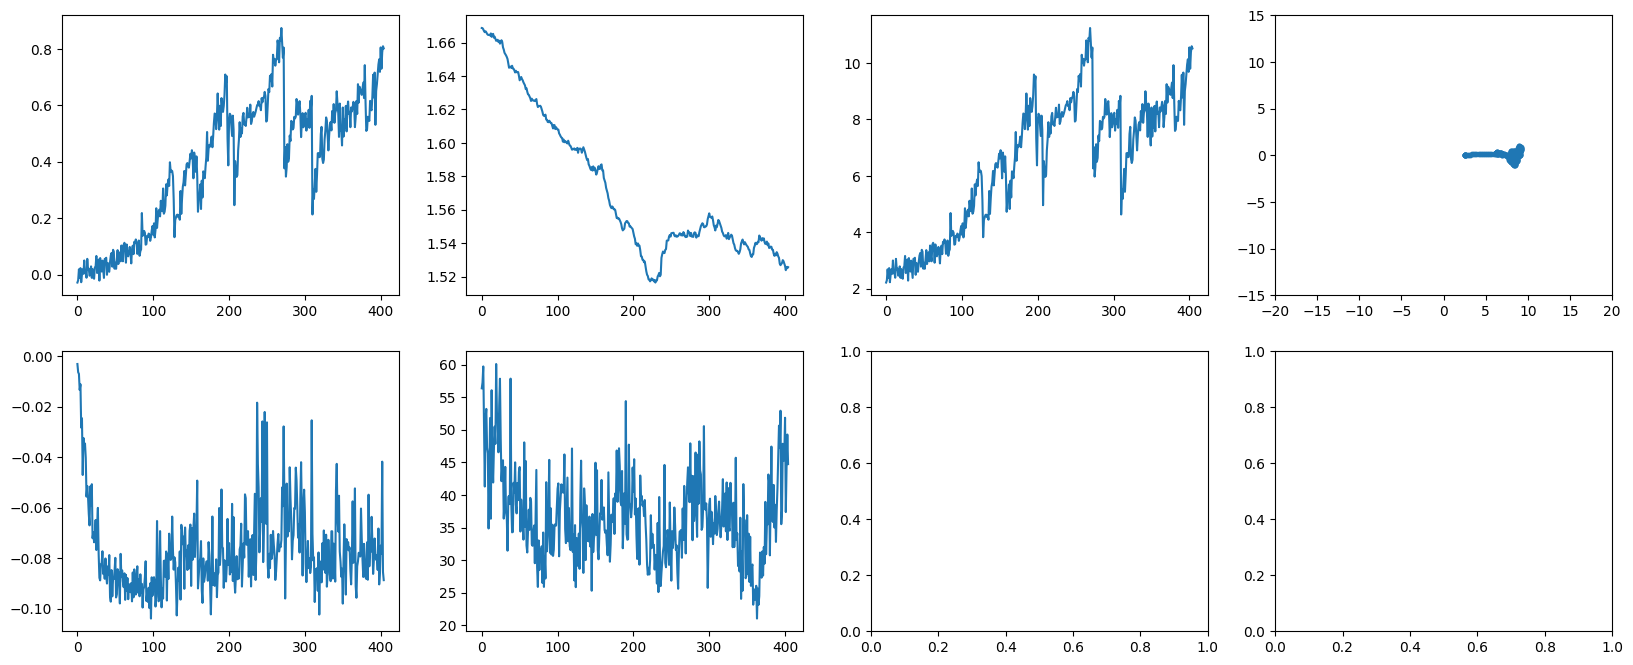

  0%|          | 0/200 [00:00<?, ?it/s]

ValueError: Expected parameter loc (Tensor of shape (1024, 8)) of distribution Normal(loc: torch.Size([1024, 8]), scale: torch.Size([1024, 8])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [114]:
model = ActorCriticContinuous(
    state_dim=env.state_dim,
    z_dim=reward_generator.len_params,
    action_dim=env.action_dim,
    actor_hidden_layers=[512, 512, 512, 512],
    critic_hidden_layers=[512, 512, 512, 512]
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

reward_generator.compute_z_over_all_trajectories()


anchors_list = []
distance2goal = []
rewards_list_1, entropies_1 = [], []
policy_losses = []
value_losses = []
last_reached_cell = []

for step in tqdm(range(500), desc='Policy training', leave=False):
    TEMP_EPISODE_LENGTH = 200
    info = train_on_new_states(env, model, optimizer, reward_generator, num_policy_steps=TEMP_EPISODE_LENGTH, target_model=None)
    anchors_list.append(info['anchors'])
    policy_losses.append(info['policy_loss'])
    value_losses.append(info['value_loss'])
    last_reached_cell.append(info['trajectory']['states'].reshape(num_envs, 200, 29)[:, -1, 0].mean())
    rewards_list_1.append(info['trajectory']['rewards'].mean().item())
    # rewards_list_1.append(info['avg_reward'])
    entropies_1.append(info['entropy'])
    # distance2goal.append(
    #     (info['trajectory']['states'].reshape(-1, TEMP_EPISODE_LENGTH, 4)[:, -1, :2] - info['anchors'][:, -1].cpu()).pow(2).sum(1).mean().item()
    # )
    
    if step % 1 == 0:
        clear_output(True)
        fig, axs = plt.subplots(2, 4, figsize=(20, 8))
        axs[0, 0].plot(rewards_list_1)
        axs[0, 1].plot(entropies_1)
        axs[0, 2].plot(last_reached_cell)
        
        coords = info['trajectory']['states'][:TEMP_EPISODE_LENGTH, :2].cpu()
        demo = info['anchors'][0, :].cpu()
        axs[0, 3].scatter(coords[:, 0], coords[:, 1], s=10)
        # axs[0, 3].scatter(demo[:, 0], demo[:, 1], s=10)
        
        # mid = info['trajectory']['states'].reshape(-1, TEMP_EPISODE_LENGTH, 4)[0, 399, :2]
        # mid_demo = info['get_training_data:info']['base_anchors'][0, -1]

        # axs[0, 3].scatter(mid[0], mid[1], marker='x', s=100, c='blue')
        # axs[0, 3].scatter(mid_demo[0], mid_demo[1], marker='x', s=100, c='red')
        # add_largest_maze_walls(axs[0, 3])
        axs[0, 3].set_xlim([-20, 20])
        axs[0, 3].set_ylim([-15, 15])
        
        axs[1, 0].plot(policy_losses)
        axs[1, 1].plot(value_losses)
                
        
        
        plt.show()  

tensor(17.5820)

In [ ]:
# torch.save(reward_generator.fre_network.state_dict(), 'models/online_fre_network_3.pth')
# torch.save(model.state_dict(), 'models/online_ppo_model_3.pth')

In [ ]:
# torch.save(reward_generator.new_states_buffer, 'antamze_states_buffer.pth')

In [52]:
reward_generator.new_states_buffer = torch.load('antamze_states_buffer.pth')

# cond = (reward_generator.new_states_buffer[:, -1, 1] > -0.5) & (reward_generator.new_states_buffer[:, -1, 1] < 0) & (reward_generator.new_states_buffer[:, -1, 0] > 2)
# cond = (reward_generator.new_states_buffer[:, -1, 1] > 1) & (reward_generator.new_states_buffer[:, -1, 1] < 1.1) & (reward_generator.new_states_buffer[:, -1, 0] < 0)
# cond = (reward_generator.new_states_buffer[:, -1, 1] > 1) & (reward_generator.new_states_buffer[:, -1, 1] < 10) & (reward_generator.new_states_buffer[:, -1, 0] > 2.4)
# cond = (reward_generator.new_states_buffer[:, -1, 1] > -10) & (reward_generator.new_states_buffer[:, -1, 1] < -1) & (reward_generator.new_states_buffer[:, -1, 0] > 2.4)
cond = (reward_generator.new_states_buffer[:, -1, 1] > 0) & (reward_generator.new_states_buffer[:, -1, 0] < -5)


print(cond.sum())

reward_generator.new_states_buffer = reward_generator.new_states_buffer[cond][[1]]

resampler = RNDResampling()
dataset = reward_generator.new_states_buffer[:, -1, :2].reshape(-1, 2)
resampler_losses = resampler.fit(dataset, epochs=1000)
resampling_weights = resampler.get_resampling_weights(dataset)
reward_generator.resampling_weights = resampling_weights

tensor(3)


/tmp/ipykernel_7665/3724040975.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reward_generator.new_states_buffer = torch.load('antamze_states_buffer.pth')


  0%|          | 0/1000 [00:00<?, ?it/s]

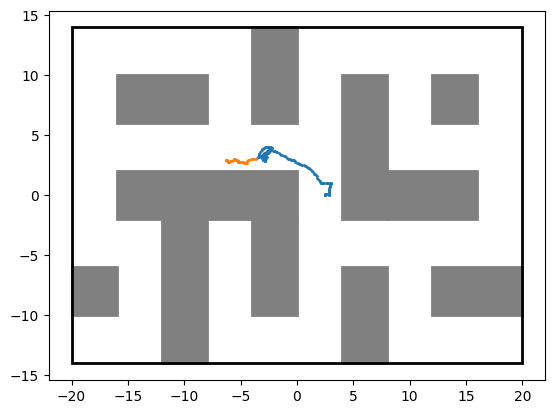

In [55]:
fig, ax = plt.subplots(1, 1)

i = 4

x = reward_generator.new_states_buffer[:, :EPISODE_LENGTH, :]
ax.scatter(x[..., 0], x[..., 1], s=1, alpha=1)

x = reward_generator.new_states_buffer[:, EPISODE_LENGTH:, :]
ax.scatter(x[..., 0], x[..., 1], s=1, alpha=1)

add_largest_maze_walls(ax)

# reward_generator.new_states_buffer
# plt.xlim([-2, 2])
# plt.xlim([-2, 2])

---

In [ ]:
def visualize_rewards_and_trajectories(eval_z, reward_generator, anchors=None, anchors_rewards=None, trajectories=None, select_max_trajectory=False):
    # eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)

    s = 100
    x1_vals = np.linspace(-20, 20, s)
    x2_vals = np.linspace(-14, 14, s)



    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
    # print(X1.shape, X2.shape)

    state = torch.zeros((s*s, 4), dtype=torch.float32)
    state[:, :2] = torch.tensor(state_x12)
    state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
    state = state.to(device)


    num_evals = eval_z.shape[0]
    num_rows = int(np.floor(num_evals/4))
    num_rows += 1 if num_evals % (num_rows*4) != 0 else 0
    fig, axs = plt.subplots(num_rows, 4, figsize=(20, num_rows*4))
    axs = axs.flatten()

    for i in range(len(eval_z)):
        zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
        with torch.no_grad():
            r = reward_generator.get_reward(state[..., :2], zi).cpu()
            # r = state[..., 1].cpu() / 10
        
        # axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.3, s=20)
        # axs[i].scatter(coods[:, 0].cpu(), coods[:, 1].cpu(), c='red', alpha=0.3, s=20)
        axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), shading='gouraud', alpha=1, vmin=0.0, vmax=1)
        # axs[i].contourf(X1, X2, r.reshape(X1.shape), levels=20, alpha=1, vmin=0.1, vmax=1.0)
        
        if anchors is not None and anchors_rewards is not None:
            axs[i].scatter(anchors[i, :, 0].cpu(), anchors[i, :, 1].cpu(), c='red', s=anchors_rewards[i, :, 0].reshape(-1).cpu()*10)
        # axs[i].scatter(anchors[i, -1, 0].cpu(), anchors[i, -1, 1].cpu(), c=anchors_rewards[i, -1, 0],  edgecolors='red', vmin=0, vmax=1)
        # axs[i].scatter(anchors[i, 0, 0].cpu(), anchors[i, 0, 1].cpu(), c='red', s=anchors_rewards[i, 0, 0].reshape(-1).cpu()*100)
        # axs[i].scatter(info['get_training_data:info']['base_anchors'][i, -1, 0].cpu(), info['get_training_data:info']['base_anchors'][i, -1, 1].cpu(), c='red', s=anchors_rewards[i, -1, 0].reshape(-1).cpu()*10)
        
        if trajectories is not None:
            if select_max_trajectory:
                # j = np.argmax([trajectories[j][0]['rewards'][TEMP_EPISODE_LENGTH*i:TEMP_EPISODE_LENGTH*(i+1)][-10:].mean() for j in range(len(trajectories))])
                max_j = np.argmax([trajectories[j][0]['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)].sum() for j in range(len(trajectories))])
                # trajectories = [trajectories[j]]
                
            for j in range(len(trajectories)):
                if select_max_trajectory:
                    j = max_j
                    
                trajectory, _ = trajectories[j]
                coords = trajectory['states'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
                r_mean = trajectory['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)][-10:].mean()
                axs[i].scatter(coords[:, 0], coords[:, 1], s=10, c='black')
                
                axs[i].set_xlabel("X-Coordinates")
                axs[i].set_xlabel(f"{r_mean}")
                axs[i].set_ylabel("Y-Coordinates")
                
                if select_max_trajectory:
                    break
        
        add_largest_maze_walls(axs[i])
        
        r_argmax = state[r.argmax(), :2].cpu()
        axs[i].scatter(r_argmax[0].cpu(), r_argmax[1].cpu(), c='green', s=10)

    plt.show()

In [ ]:
# eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)
eval_z, info = reward_generator.get_z_from_random_anchors(eval_num_envs, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS)
# eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)
base_z = info['base_z']

anchors, anchors_rewards = info['anchors'], info['anchors_rewards']

In [ ]:
trajectories = []
for _ in tqdm(range(1)):trajectories.append(collect_trajectories(eval_env, eval_z, model, n_steps=EPISODE_LENGTH, reward_generator=reward_generator))
# for _ in tqdm(range(1)):trajectories.append(collect_trajectories(eval_env, base_z, model, n_steps=EPISODE_LENGTH, reward_generator=reward_generator))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

tensor(0)


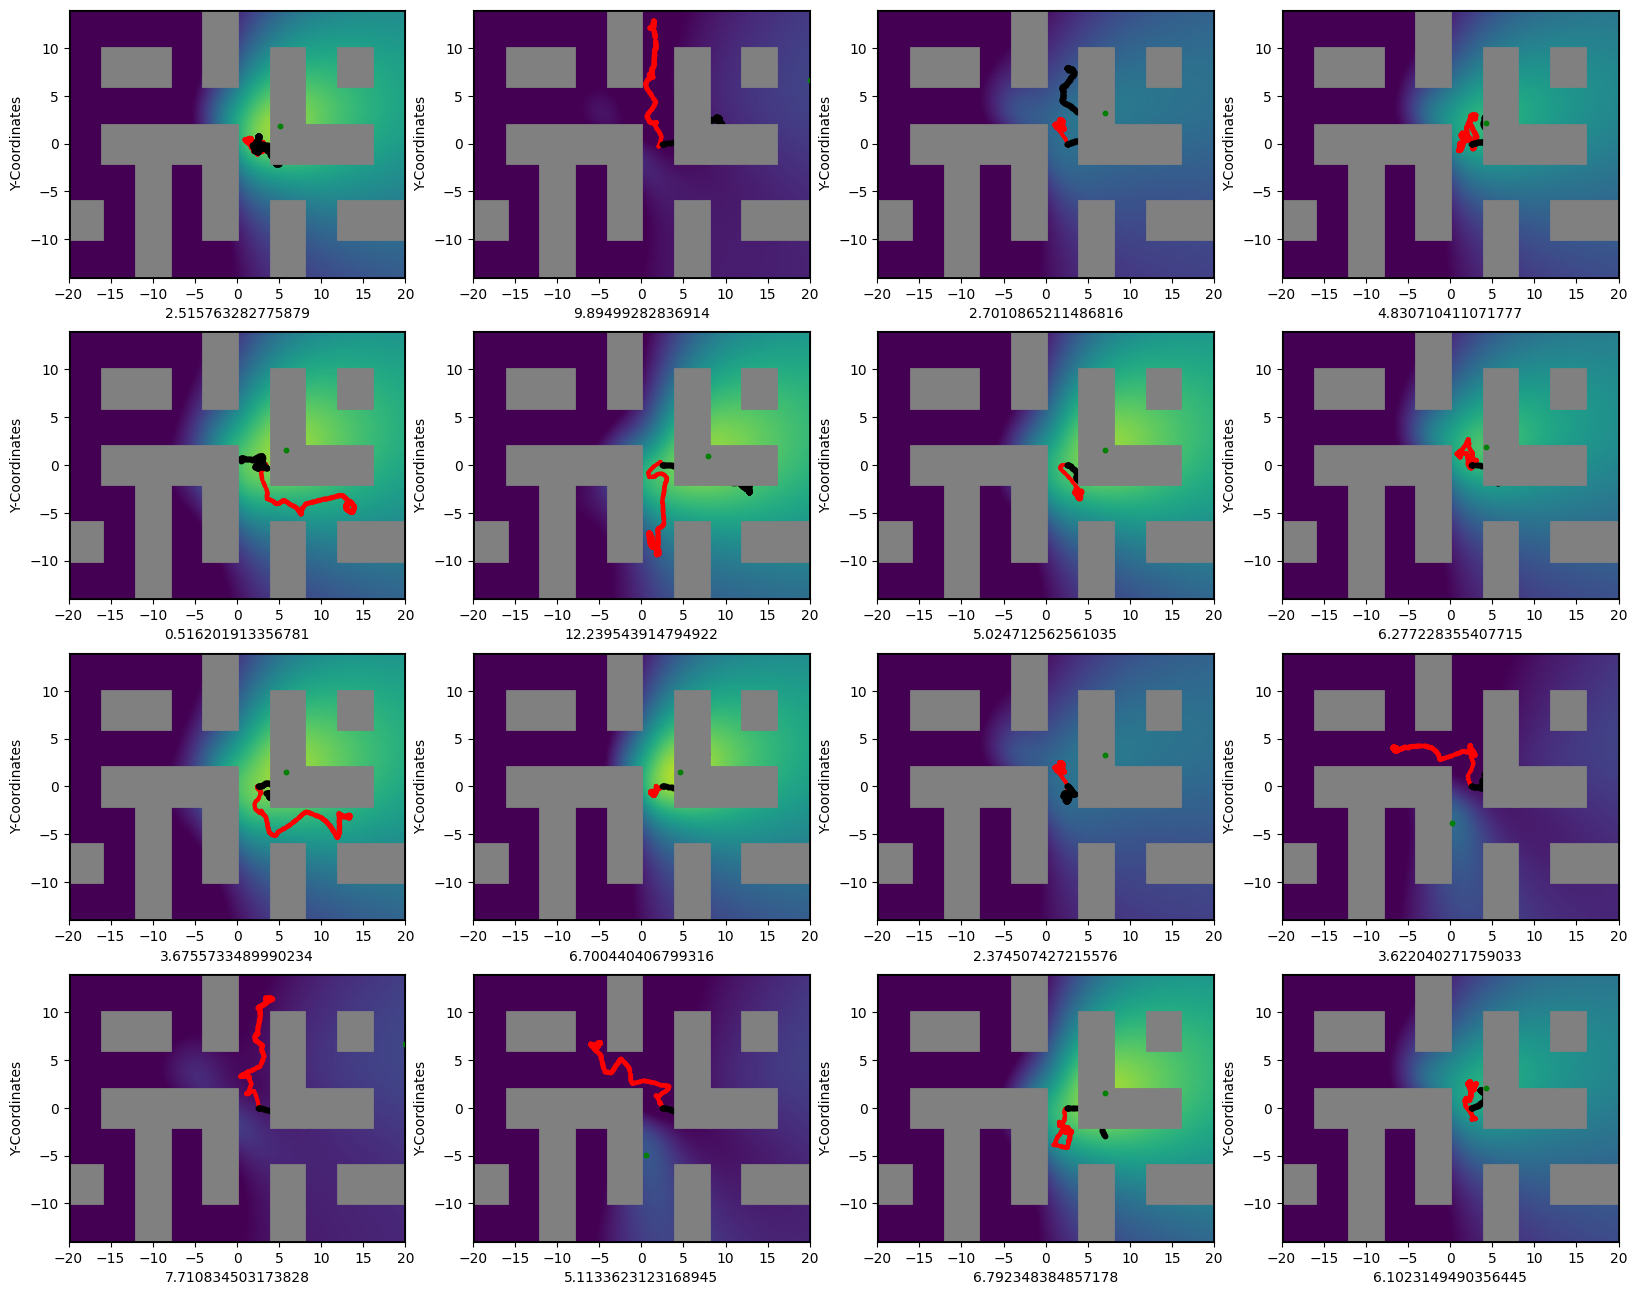

In [ ]:
visualize_rewards_and_trajectories(eval_z, reward_generator, anchors, anchors_rewards, trajectories, select_max_trajectory=True)

In [ ]:
s = 100
x1_vals = np.linspace(-X1_RANGE, X1_RANGE, s)
x2_vals = np.linspace(-X2_RANGE, X2_RANGE, s)

# x1_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE
# x2_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE

# x1_vals = np.linspace(-0.3, 0.3, s)
# x1_vals = np.round((x1_vals + 0.3) / 0.6 * 32)
# x2_vals = np.linspace(-0.3, 0.3, s)
# x2_vals = np.round((x2_vals + 0.3) / 0.6 * 32)



X1, X2 = np.meshgrid(x1_vals, x2_vals)
state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
# print(X1.shape, X2.shape)

state = torch.zeros((s*s, 4), dtype=torch.float32)
state[:, :2] = torch.tensor(state_x12)
state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
state = state.to(device)

coods = reward_generator.new_states_buffer.reshape(-1, 2).to(device)

fig, axs = plt.subplots(4, 4, figsize=(20, 16))
axs = axs.flatten()

for i in tqdm(range(len(eval_z))):
    zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
    with torch.no_grad():
        r = reward_generator.get_reward(state[..., :2], zi).cpu()
    
    # axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.3, s=20)
    # axs[i].scatter(coods[:, 0].cpu(), coods[:, 1].cpu(), c='red', alpha=0.3, s=20)
    # axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), shading='gouraud', alpha=1, vmin=0.0, vmax=1)
    axs[i].contourf(X1, X2, r.reshape(X1.shape), levels=20, alpha=1, vmin=0.1, vmax=1.0)
    axs[i].scatter(anchors[i, :, 0].cpu(), anchors[i, :, 1].cpu(), c='red', s=anchors_rewards[i, :, 0].reshape(-1).cpu()*10)
    # axs[i].scatter(anchors[i, -1, 0].cpu(), anchors[i, -1, 1].cpu(), c=anchors_rewards[i, -1, 0],  edgecolors='red', vmin=0, vmax=1)
    # axs[i].scatter(anchors[i, 0, 0].cpu(), anchors[i, 0, 1].cpu(), c='red', s=anchors_rewards[i, 0, 0].reshape(-1).cpu()*100)
    axs[i].scatter(info['get_training_data:info']['base_anchors'][i, -1, 0].cpu(), info['get_training_data:info']['base_anchors'][i, -1, 1].cpu(), c='red', s=anchors_rewards[i, -1, 0].reshape(-1).cpu()*10)
    
    r_argmax = state[r.argmax(), :2].cpu()
    
    
    
    for j in range(len(trajectories)):
        trajectory, _ = trajectories[j]
        coords = trajectory['states'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
        r_mean = trajectory['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)][-10:].mean()
        axs[i].scatter(coords[:, 0], coords[:, 1], alpha=np.linspace(0.0, 1, len(coords)), s=10, c='black')
        # axs[i].scatter(coords[EPISODE_LENGTH//4*3, 0], coords[EPISODE_LENGTH//4*3, 1], s=100, c='black', marker='x')
        
        v = trajectory['actions'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
        for c in range(0, len(coords), 50):
            x, y = coords[c]
            vx, vy = v[c:c+50].mean(0) / 10
            # axs[i].arrow(x, y, vx, vy, head_width=0.05, fc='red', ec='red')
        
        axs[i].set_xlabel("X-Coordinates")  # Change this to your appropriate label
        axs[i].set_xlabel(f"{r_mean}")
        axs[i].set_ylabel("Y-Coordinates")
        # axs[i].set_xlim([-2, 2])
        # axs[i].set_ylim([-2, 2])
    add_largest_maze_walls(axs[i])
    
    axs[i].scatter(r_argmax[0].cpu(), r_argmax[1].cpu(), c='green', s=10)

plt.show()

---

---

---

In [ ]:
# torch.save(reward_generator_2.fre_network.state_dict(), 'reward_generator_2-fre_network.pth')

num_anchors = 8

fre_network = FRENetwork(obs_len=2)
fre_network.load_state_dict(torch.load('reward_generator_2-fre_network.pth'))

reward_generator_2 = RewardGenerator(
    obs_dim=2,
    fre_network=fre_network,
    min_num_anchors=num_anchors,
    max_num_anchors=num_anchors,
    from_buffer=True
)
reward_generator_2.new_states_buffer = torch.load('models/new_states_buffer_14.pth')['new_states_buffer']
if reward_generator_2.new_states_buffer is not None:
    resampler = RNDResampling()
    dataset = reward_generator_2.new_states_buffer[:, -1, :].reshape(-1, 2)
    resampler_losses = resampler.fit(dataset, epochs=1000)
    resampling_weights = resampler.get_resampling_weights(dataset)
    reward_generator_2.resampling_weights = resampling_weights

vae_loss, vae_kl_loss = [], []

In [ ]:
# print('VAE training...')
# for step in tqdm(range(10000), desc='VAE training', leave=False):
    
#     vae_loss_dict = reward_generator_2.train_step_VAE(
#         batch_size=256,
#         min_num_anchors=num_anchors,
#         max_num_anchors=num_anchors,
#         from_new_states=True,
#         num_states=num_anchors+1,
#         non_anchor_coef=0.0,
#         anchors_from_same_trajectory=False
#     )
#     vae_loss.append(vae_loss_dict['loss'])
#     vae_kl_loss.append(vae_loss_dict['kl_loss'])   
    
#     if step % 10 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
#         axs[0].plot(vae_loss)
#         axs[0].set_ylim([0, 0.5])
#         axs[1].plot(vae_kl_loss)
#         axs[1].set_ylim([0, 1])
#         plt.show() 



In [ ]:
eval_z, info = reward_generator_2.get_z_from_random_anchors(eval_num_envs, min_num_anchors=num_anchors, max_num_anchors=num_anchors, anchors_from_same_trajectory=False)
# eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)
# base_z = info['base_z']

anchors, anchors_rewards = info['anchors'], info['anchors_rewards']

visualize_rewards_and_trajectories(eval_z, reward_generator_2, anchors, anchors_rewards)

In [ ]:
reward_generator.compute_z_over_all_trajectories()

In [ ]:
batch_size = 32
num_random_samples = 200

In [ ]:
reward_encoder = FRENetwork(obs_len=2, num_heads=2, num_layers=2).to(device)
reward_encoder_optimizer = torch.optim.Adam(reward_encoder.parameters(), lr=0.001)
reward_encoder_loss = []

In [ ]:

for epoch in tqdm(range(10000)):
    with torch.no_grad():
        reward_w, info = reward_generator_2.get_z_from_random_anchors(batch_size, min_num_anchors=8, max_num_anchors=8, anchors_from_same_trajectory=False)
        
    # break
    # Get the representation of the reward function based on random states:

    buffer = reward_generator_2.new_states_buffer
    trajectories_idx = reward_generator_2.get_importance_sampling_indices(num_random_samples*batch_size)
    trajectories_idx_ = trajectories_idx
    states_idx = torch.randint(0, buffer.shape[1], (num_random_samples*batch_size,))
    states_idx = torch.full_like(states_idx, fill_value=249)
    random_states = buffer[trajectories_idx, states_idx]
    random_states = random_states.reshape(batch_size, num_random_samples, 2).to(device)

    with torch.no_grad():
        random_states_rewards = reward_generator_2.get_reward(
            random_states.reshape(-1, 2),
            reward_w.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        )
    random_states_rewards = random_states_rewards.reshape(batch_size, num_random_samples)

    # random_states, random_states_rewards = info['anchors'].to(device), info['anchors_rewards'].to(device)

    pad_mask = torch.full((batch_size, num_random_samples), fill_value=False, device=device)
    new_reward_w, _ = reward_encoder.get_transformer_encoding(
        random_states, 
        random_states_rewards, 
        pad_mask=pad_mask
    )
    
    # loss = (new_reward_w - reward_w).pow(2).sum(-1).mean()

    # break

    # Find the best trajectory for each reward funciton:

    best_traj_w = []
    best_traj_id = []

    for i in range(batch_size):
        x = reward_generator.new_states_buffer[:, ::20, :]
        num_trajectories, steps, _ = x.shape
        
        x = x.reshape(-1, 2).to(device)
        w = reward_w[[i]].repeat(x.shape[0], 1)

        with torch.no_grad():
            r = reward_generator_2.get_reward(x, w).reshape(num_trajectories, steps)
            cumm_r = r.sum(-1)
        
        trag_max_id = cumm_r.argmax()
        best_traj_id.append(trag_max_id.item())
        best_traj_w.append(reward_generator.pre_computed_zs[cumm_r.argmax()])
        
    best_traj_w = torch.stack(best_traj_w)

    
    loss = (best_traj_w - new_reward_w).pow(2).sum(-1).mean()
    

    reward_encoder_optimizer.zero_grad()
    loss.backward()
    reward_encoder_optimizer.step()


    reward_encoder_loss.append(loss.item())
    
    if epoch % 10 == 0:
        clear_output(True)
        plt.plot(reward_encoder_loss)
        # plt.ylim([0, 5])
        plt.show()
        
    # break


In [ ]:
visualize_rewards_and_trajectories(reward_w[:15], reward_generator_2)

In [ ]:
visualize_rewards_and_trajectories(new_reward_w[:7].detach(), reward_generator)

In [ ]:
batch_size = 16

with torch.no_grad():
    reward_w, _ = reward_generator_2.get_z_from_random_anchors(batch_size, min_num_anchors=8, max_num_anchors=8, anchors_from_same_trajectory=False)


buffer = reward_generator_2.new_states_buffer
trajectories_idx = reward_generator_2.get_importance_sampling_indices(num_random_samples*batch_size)
states_idx = torch.randint(0, buffer.shape[1], (num_random_samples*batch_size,))
random_states = buffer[trajectories_idx, states_idx].reshape(batch_size, num_random_samples, 2).to(device)


with torch.no_grad():
    random_states_rewards = reward_generator_2.get_reward(
        random_states.reshape(-1, 2),
        reward_w.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
    ).reshape(batch_size, num_random_samples)


pad_mask = torch.full((batch_size, num_random_samples), fill_value=False, device=device)
new_reward_w, _ = reward_encoder.get_transformer_encoding(random_states, random_states_rewards, pad_mask=pad_mask)
new_reward_w = new_reward_w[:16]

In [ ]:
# x = reward_generator.new_states_buffer[:, ::20, :]
# num_trajectories, steps, _ = x.shape

# x = x.reshape(-1, 2).to(device)
# w = reward_w[[3]].repeat(x.shape[0], 1)

# with torch.no_grad():
#     r = reward_generator_2.get_reward(x, w).reshape(num_trajectories, steps)
#     cumm_r = r.sum(-1)
    
    
# print(cumm_r.argmax())
# best_traj = reward_generator.new_states_buffer[cumm_r.argmax()]

# fig, axs = plt.subplots(1, 1)
# axs.scatter(best_traj[:, 0], best_traj[:, 1])
# add_largest_maze_walls(axs)

In [ ]:
trajectories = []
for _ in tqdm(range(5)):trajectories.append(collect_trajectories(eval_env, new_reward_w[:16], model, n_steps=EPISODE_LENGTH, reward_generator=reward_generator))
# for _ in tqdm(range(5)):trajectories.append(collect_trajectories(eval_env, reward_generator.pre_computed_zs[[1586]].repeat(16, 1), model, n_steps=EPISODE_LENGTH, reward_generator=reward_generator))

visualize_rewards_and_trajectories(reward_w[:16], reward_generator_2, trajectories=trajectories, select_max_trajectory=True)